# Fine-tuning T5 for SQuAD Question Answering

**Name:** Haikal Ali  
**Class:** TK-46-GAB  
**NIM:** 1103223071  

## Objective

This notebook implements an end-to-end Transformer fine-tuning pipeline for **Question Answering** using **T5-base** and the **SQuAD** dataset.

The model receives a question and a context paragraph, then generates the answer as text.

Pipeline:

1. Load SQuAD dataset
2. Inspect and preprocess the data
3. Format question-answer pairs into T5 text-to-text format
4. Tokenize input and target text
5. Fine-tune `t5-base`
6. Generate answers
7. Evaluate using Exact Match and F1
8. Save metrics, predictions, and report


## 1. Install Dependencies

Run this cell first in Google Colab. Use GPU runtime:

`Runtime > Change runtime type > GPU`


In [1]:
!pip -q install -U transformers datasets accelerate evaluate sentencepiece pandas numpy scikit-learn matplotlib tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/

## 2. Import Libraries and Set Configuration


In [2]:
# Stable dependency setup for Google Colab / Kaggle.
# Fixes NumPy binary/version conflict:
# ImportError: cannot import name '_center' from 'numpy._core.umath'

!pip -q install --upgrade --force-reinstall --no-cache-dir \
  "numpy==1.26.4" \
  "pandas==2.2.2" \
  "scikit-learn==1.5.2"

!pip -q install --upgrade --no-cache-dir \
  "transformers==4.44.2" \
  "datasets==2.21.0" \
  "accelerate==0.33.0" \
  "evaluate==0.4.2" \
  "sentencepiece==0.2.0" \
  "rouge-score==0.1.2" \
  "matplotlib==3.9.2" \
  "tqdm==4.66.5"

print("Dependency installation completed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 163.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 213.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 298.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 223.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 256.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 293.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 re

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import os
import re
import json
import math
import random
import string
import inspect
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
  AutoTokenizer,
  AutoModelForSeq2SeqLM,
  DataCollatorForSeq2Seq,
  Seq2SeqTrainer,
  Seq2SeqTrainingArguments,
  set_seed
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

STUDENT_NAME = "Haikal Ali"
CLASS_NAME = "TK-46-GAB"
NIM = "1103223071"
GROUP_NAME = "Fill in your group name"

MODEL_NAME = "t5-base"
OUTPUT_DIR = "t5_squad_outputs"

TRAIN_SAMPLES = 2000
VALID_SAMPLES = 400
TEST_SAMPLES = 200

MAX_SOURCE_LENGTH = 384
MAX_TARGET_LENGTH = 48

NUM_EPOCHS = 1
LEARNING_RATE = 3e-4
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4

Path("outputs").mkdir(exist_ok=True)
Path("reports").mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))
else:
  print("No GPU detected. Training will be slow. Use Google Colab GPU runtime.")


Device: cuda
GPU: Tesla T4


## 3. Load SQuAD Dataset

SQuAD contains context paragraphs, questions, and reference answers.  
The original dataset is large, so this notebook uses a controlled subset to keep the experiment practical on Google Colab.


In [2]:
raw_dataset = load_dataset("squad")

print(raw_dataset)
print("\nTrain columns:", raw_dataset["train"].column_names)
print("Validation columns:", raw_dataset["validation"].column_names)

sample = raw_dataset["train"][0]
sample


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

Train columns: ['id', 'title', 'context', 'question', 'answers']
Validation columns: ['id', 'title', 'context', 'question', 'answers']


{'id': '5733be284776f41900661182',
 'title': 'University_of_Notre_Dame',
 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?',
 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}

## 4. Create Train, Validation, and Test Subsets

SQuAD only provides `train` and `validation` splits.  
This notebook uses:

- train subset from `train`
- validation subset from the first part of `validation`
- test subset from the next part of `validation`

This keeps evaluation separated from training.


In [3]:
train_dataset = raw_dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SAMPLES))

validation_pool = raw_dataset["validation"].shuffle(seed=SEED)
valid_dataset = validation_pool.select(range(VALID_SAMPLES))
test_dataset = validation_pool.select(range(VALID_SAMPLES, VALID_SAMPLES + TEST_SAMPLES))

print(train_dataset)
print(valid_dataset)
print(test_dataset)


Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 2000
})
Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 400
})
Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 200
})


## 5. Exploratory Data Analysis

This section checks example structure, context length, question length, and answer length.


In [4]:
def make_eda_frame(dataset, n=1000):
  n = min(n, len(dataset))
  rows = []

  for item in dataset.select(range(n)):
    answer_texts = item["answers"]["text"]
    answer = answer_texts[0] if len(answer_texts) > 0 else ""

    rows.append({
      "id": item["id"],
      "title": item["title"],
      "question": item["question"],
      "context": item["context"],
      "answer": answer,
      "question_words": len(item["question"].split()),
      "context_words": len(item["context"].split()),
      "answer_words": len(answer.split())
    })

  return pd.DataFrame(rows)

eda_df = make_eda_frame(train_dataset, n=1000)

display(eda_df.head())
display(eda_df[["question_words", "context_words", "answer_words"]].describe())


,id,title,question,context,answer,question_words,context_words,answer_words
0,573173d8497a881900248f0c,Egypt,What percentage of Egyptians polled support de...,The Pew Forum on Religion & Public Life ranks ...,84%,12,110,1
1,57277e815951b619008f8b52,"Ann_Arbor,_Michigan",Ann Arbor ranks 1st among what goods sold?,The Ann Arbor Hands-On Museum is located in a ...,books,8,98,1
2,5727e2483acd2414000deef0,Rule_of_law,"In developing countries, who makes most of the...",One important aspect of the rule-of-law initia...,the executive,10,117,2
3,5728f5716aef0514001548cc,Samurai,Who impressed Xavier by taking notes in church?,"In December 1547, Francis was in Malacca (Mala...",Anjiro,8,108,1
4,572826002ca10214002d9f16,Group_(mathematics),What represents elements of the fundamental gr...,Groups are also applied in many other mathemat...,loops,7,157,1


,question_words,context_words,answer_words
count,1000.000000,1000.000000,1000.000000
mean,10.018000,118.975000,3.233000
std,3.538106,48.274038,3.631515
min,3.000000,20.000000,1.000000
25%,8.000000,88.000000,1.000000
50%,9.500000,109.000000,2.000000
75%,12.000000,141.000000,3.000000
max,25.000000,333.000000,29.000000


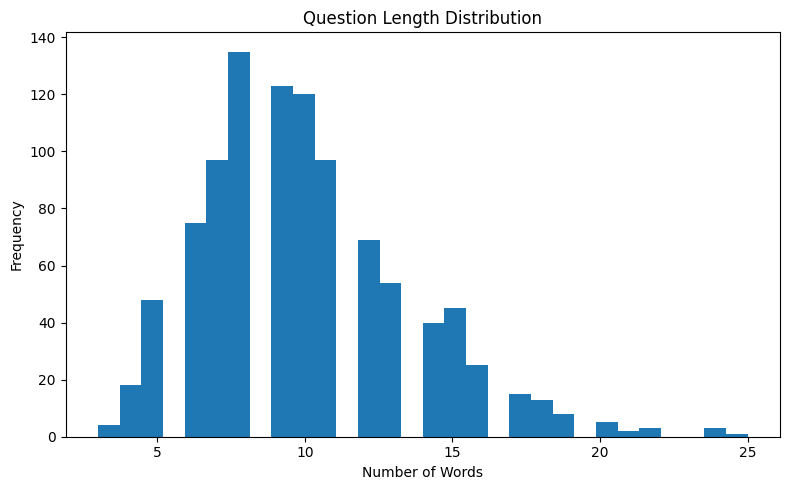

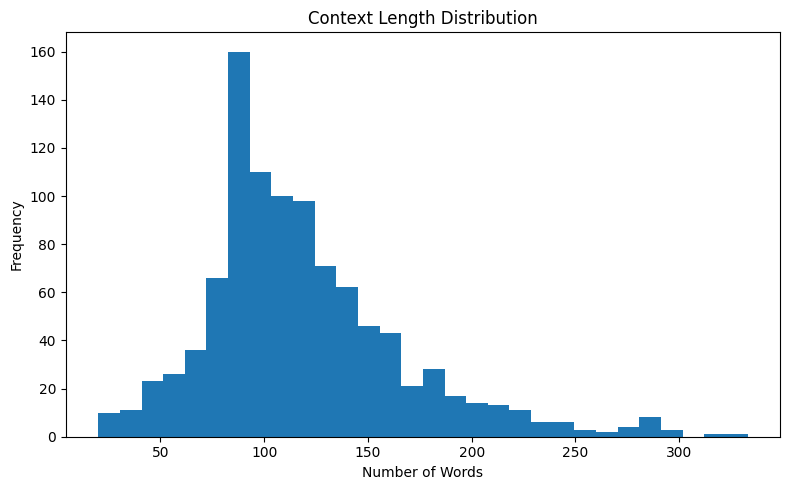

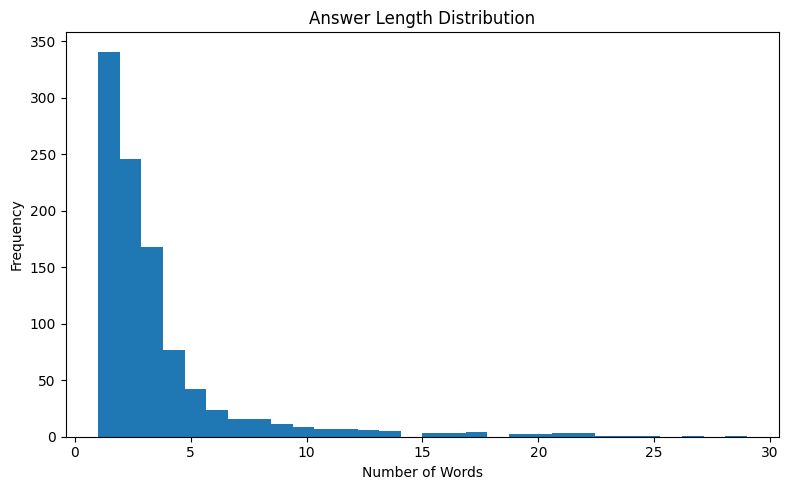

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(eda_df["question_words"], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(eda_df["context_words"], bins=30)
plt.title("Context Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(eda_df["answer_words"], bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 6. Prepare Text-to-Text Format for T5

T5 expects every task to be represented as text-to-text generation.

Input format:

```txt
question: <question> context: <context>
```

Target format:

```txt
<answer>
```


In [6]:
def build_t5_input(question, context):
  question = question.strip()
  context = context.strip()
  return f"question: {question} context: {context}"

def get_first_answer(answers):
  if len(answers["text"]) == 0:
    return ""
  return answers["text"][0].strip()

formatted_example = {
  "input_text": build_t5_input(sample["question"], sample["context"]),
  "target_text": get_first_answer(sample["answers"])
}

formatted_example


{'input_text': 'question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? context: Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
 'target_text': 'Saint Bernadette Soubirous'}

## 7. Load Tokenizer and Model


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model = model.to(device)

print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Model:", MODEL_NAME)


config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Tokenizer vocab size: 32100
Model: t5-base


## 8. Tokenization

The input sequence is truncated to `MAX_SOURCE_LENGTH`.  
The target answer is truncated to `MAX_TARGET_LENGTH`.


In [8]:
def preprocess_function(examples):
  inputs = [
    build_t5_input(question, context)
    for question, context in zip(examples["question"], examples["context"])
  ]

  targets = [
    get_first_answer(answers)
    for answers in examples["answers"]
  ]

  model_inputs = tokenizer(
    inputs,
    max_length=MAX_SOURCE_LENGTH,
    truncation=True
  )

  labels = tokenizer(
    text_target=targets,
    max_length=MAX_TARGET_LENGTH,
    truncation=True
  )

  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

tokenized_train = train_dataset.map(
  preprocess_function,
  batched=True,
  remove_columns=train_dataset.column_names
)

tokenized_valid = valid_dataset.map(
  preprocess_function,
  batched=True,
  remove_columns=valid_dataset.column_names
)

tokenized_test = test_dataset.map(
  preprocess_function,
  batched=True,
  remove_columns=test_dataset.column_names
)

print(tokenized_train)
print(tokenized_valid)
print(tokenized_test)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 400
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 200
})


## 9. Define Evaluation Metrics

This notebook uses standard SQuAD-style text normalization:

- lowercase
- remove punctuation
- remove articles
- remove extra whitespace

Metrics:

- **Exact Match (EM):** generated answer exactly matches reference answer after normalization
- **F1:** token-level overlap between generated and reference answer


In [13]:
def normalize_answer(text):
  def lower(s):
    return s.lower()

  def remove_punc(s):
    return "".join(ch for ch in s if ch not in set(string.punctuation))

  def remove_articles(s):
    return re.sub(r"\b(a|an|the)\b", " ", s)

  def white_space_fix(s):
    return " ".join(s.split())

  return white_space_fix(remove_articles(remove_punc(lower(text))))

def exact_match_score(prediction, ground_truth):
  return int(normalize_answer(prediction) == normalize_answer(ground_truth))

def token_f1_score(prediction, ground_truth):
  pred_tokens = normalize_answer(prediction).split()
  truth_tokens = normalize_answer(ground_truth).split()

  if len(pred_tokens) == 0 and len(truth_tokens) == 0:
    return 1.0

  if len(pred_tokens) == 0 or len(truth_tokens) == 0:
    return 0.0

  common = Counter(pred_tokens) & Counter(truth_tokens)
  num_same = sum(common.values())

  if num_same == 0:
    return 0.0

  precision = num_same / len(pred_tokens)
  recall = num_same / len(truth_tokens)
  return 2 * precision * recall / (precision + recall)

def sanitize_token_ids(token_ids):
  arr = np.asarray(token_ids)

  # Kalau yang masuk logits, ubah ke token IDs
  if arr.ndim == 3:
    arr = np.argmax(arr, axis=-1)

  pad_id = tokenizer.pad_token_id
  vocab_size = len(tokenizer)

  # Fix token invalid seperti -100
  arr = np.where(arr < 0, pad_id, arr)
  arr = np.where(arr >= vocab_size, pad_id, arr)

  return arr.astype(np.int64)

def safe_batch_decode(token_ids):
  clean_ids = sanitize_token_ids(token_ids)
  return tokenizer.batch_decode(
    clean_ids.tolist(),
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
  )

def compute_metrics(eval_preds):
  preds, labels = eval_preds

  if isinstance(preds, tuple):
    preds = preds[0]

  decoded_preds = safe_batch_decode(preds)
  decoded_labels = safe_batch_decode(labels)

  em_scores = [
    exact_match_score(pred, label)
    for pred, label in zip(decoded_preds, decoded_labels)
  ]

  f1_scores = [
    token_f1_score(pred, label)
    for pred, label in zip(decoded_preds, decoded_labels)
  ]

  generated_lengths = [
    len(pred.split())
    for pred in decoded_preds
  ]

  return {
    "exact_match": round(float(np.mean(em_scores)) * 100, 4),
    "f1": round(float(np.mean(f1_scores)) * 100, 4),
    "avg_generated_length": round(float(np.mean(generated_lengths)), 4)
  }

print("EM example:", exact_match_score("Denver Broncos", "Denver Broncos"))
print("F1 example:", token_f1_score("Broncos", "Denver Broncos"))

EM example: 1
F1 example: 0.6666666666666666


## 10. Training Setup

The notebook uses gradient accumulation to reduce GPU memory pressure.

Effective batch size:

```txt
TRAIN_BATCH_SIZE x GRADIENT_ACCUMULATION_STEPS
```


In [14]:
data_collator = DataCollatorForSeq2Seq(
  tokenizer=tokenizer,
  model=model
)

args_signature = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters
strategy_key = "eval_strategy" if "eval_strategy" in args_signature else "evaluation_strategy"

training_args = Seq2SeqTrainingArguments(
  output_dir=OUTPUT_DIR,
  learning_rate=LEARNING_RATE,
  per_device_train_batch_size=TRAIN_BATCH_SIZE,
  per_device_eval_batch_size=EVAL_BATCH_SIZE,
  gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
  num_train_epochs=NUM_EPOCHS,
  weight_decay=0.01,
  save_strategy="epoch",
  logging_strategy="steps",
  logging_steps=50,
  predict_with_generate=True,
  generation_max_length=MAX_TARGET_LENGTH,
  fp16=torch.cuda.is_available(),
  report_to="none",
  save_total_limit=1,
  **{strategy_key: "epoch"}
)

trainer = Seq2SeqTrainer(
  model=model,
  args=training_args,
  train_dataset=tokenized_train,
  eval_dataset=tokenized_valid,
  tokenizer=tokenizer,
  data_collator=data_collator,
  compute_metrics=compute_metrics
)

training_args


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Seq2SeqTrainingArguments(output_dir='t5_squad_outputs', overwrite_output_dir=False, do_train=False, do_eval=True, do_predict=False, eval_strategy=<IntervalStrategy.EPOCH: 'epoch'>, prediction_loss_only=False, per_device_train_batch_size=4, per_device_eval_batch_size=4, per_gpu_train_batch_size=None, per_gpu_eval_batch_size=None, gradient_accumulation_steps=4, eval_accumulation_steps=None, eval_delay=0, torch_empty_cache_steps=None, learning_rate=0.0003, weight_decay=0.01, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=1, max_steps=-1, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs={}, warmup_ratio=0.0, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir='t5_squad_outputs/runs/Jun17_22-07-31_c7dcd44ab951', logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=50, logging_nan_inf_filter=True, save_strategy=<IntervalStrategy.EPOCH: 'epo

## 11. Fine-tune T5

This cell starts training.  
Expected runtime depends on GPU availability and selected subset size.


In [15]:
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Exact Match,F1,Avg Generated Length
1,0.140500,0.528925,64.750000,81.474700,3.255000


TrainOutput(global_step=125, training_loss=0.12717438888549804, metrics={'train_runtime': 219.4218, 'train_samples_per_second': 9.115, 'train_steps_per_second': 0.57, 'total_flos': 637631243735040.0, 'train_loss': 0.12717438888549804, 'epoch': 1.0})

## 12. Evaluate on Validation Set


In [18]:
valid_metrics = trainer.evaluate()
valid_metrics

{'eval_loss': 0.5289251804351807,
 'eval_exact_match': 64.75,
 'eval_f1': 81.4747,
 'eval_avg_generated_length': 3.255,
 'eval_runtime': 61.3934,
 'eval_samples_per_second': 6.515,
 'eval_steps_per_second': 1.629,
 'epoch': 1.0}

## 13. Evaluate on Test Set

This section generates answers for the held-out test subset and calculates metrics.


In [19]:
test_output = trainer.predict(tokenized_test)
test_metrics = test_output.metrics

test_metrics

{'test_loss': 0.5111498832702637,
 'test_exact_match': 61.5,
 'test_f1': 79.0026,
 'test_avg_generated_length': 3.58,
 'test_runtime': 21.3432,
 'test_samples_per_second': 9.371,
 'test_steps_per_second': 2.343}

## 14. Generate Predictions and Perform Error Analysis

This section compares generated answers against reference answers.


In [21]:
pred_ids = test_output.predictions

if isinstance(pred_ids, tuple):
  pred_ids = pred_ids[0]

decoded_predictions = safe_batch_decode(pred_ids)

prediction_rows = []

for idx, item in enumerate(test_dataset):
  reference_answers = item["answers"]["text"]
  prediction = decoded_predictions[idx].strip()

  em = metric_max_over_ground_truths(exact_match_score, prediction, reference_answers)
  f1 = metric_max_over_ground_truths(token_f1_score, prediction, reference_answers)

  prediction_rows.append({
    "id": item["id"],
    "title": item["title"],
    "question": item["question"],
    "context_short": item["context"][:300].replace("\n", " ") + "...",
    "reference_answers": " | ".join(reference_answers),
    "predicted_answer": prediction,
    "exact_match": em,
    "f1": f1
  })

predictions_df = pd.DataFrame(prediction_rows)

display(predictions_df.head(10))

final_exact_match = predictions_df["exact_match"].mean() * 100
final_f1 = predictions_df["f1"].mean() * 100
avg_generated_length = predictions_df["predicted_answer"].apply(lambda x: len(str(x).split())).mean()

final_metrics = {
  "test_exact_match": round(float(final_exact_match), 4),
  "test_f1": round(float(final_f1), 4),
  "avg_generated_length": round(float(avg_generated_length), 4),
  "train_samples": TRAIN_SAMPLES,
  "valid_samples": VALID_SAMPLES,
  "test_samples": TEST_SAMPLES,
  "model": MODEL_NAME,
  "dataset": "SQuAD",
  "epochs": NUM_EPOCHS,
  "learning_rate": LEARNING_RATE,
  "train_batch_size": TRAIN_BATCH_SIZE,
  "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS
}

final_metrics

,id,title,question,context_short,reference_answers,predicted_answer,exact_match,f1
0,5726d993f1498d1400e8ed1a,Victoria_and_Albert_Museum,How is the plaster replica of Verrocchio's Dav...,One of the most dramatic parts of the museum i...,in a glass case | glass case | in a glass case,in a glass case,1,1.000000
1,5726b1d95951b619008f7ace,Genghis_Khan,Why did Temüjin kill those of Jamukha's follow...,"According to the Secret History, Temüjin again...",he did not want disloyal men in his army | did...,he did not want disloyal men in his army,1,1.000000
2,572819864b864d1900164481,Doctor_Who,What was the name of the Doctor Who-related so...,"Versions of the ""Doctor Who Theme"" have also b...",Doctorin' the Tardis | Doctorin' the Tardis | ...,The Timelords,0,0.000000
3,572a0bf96aef051400155207,Immune_system,What is the chemical that mediates Type 1 hype...,Hypersensitivity is an immune response that da...,IgE | IgE | IgE,IgE,1,1.000000
4,57273455f1498d1400e8f48f,Genghis_Khan,When was the mausoleum returned to the Lord's ...,In 1939 Chinese Nationalist soldiers took the ...,"1954 | 1954 | 1954,",early 1954,0,0.666667
5,5728fc2eaf94a219006a9ecb,Immune_system,Vaginal secretions serve as a chemical protect...,Chemical barriers also protect against infecti...,menarche | menarche | menarche,menarche,1,1.000000
6,57268a37f1498d1400e8e33e,Ctenophora,What do beroids typically eat?,"Ctenophores used to be regarded as ""dead ends""...",ctenophores | other ctenophores | other ctenop...,other ctenophores,1,1.000000
7,5726ea06dd62a815002e950d,American_Broadcasting_Company,"In 1951, rumors claimed that ABC might be sold...","At the end of 1949, movie theater operator Uni...",CBS | CBS | CBS,CBS,1,1.000000
8,56d9ba95dc89441400fdb754,Super_Bowl_50,What agency did the Spanish version of the Sup...,"On December 28, 2015, ESPN Deportes announced ...",ESPN Deportes | ESPN Deportes | ESPN Deportes,CBS,0,0.000000
9,57263ea0271a42140099d7c4,Packet_switching,What did DECnet originally do,DECnet is a suite of network protocols created...,connect two PDP-11 minicomputers | connect two...,originally released in 1975 in order to connec...,0,0.533333


{'test_exact_match': 74.0,
 'test_f1': 85.6452,
 'avg_generated_length': 3.58,
 'train_samples': 2000,
 'valid_samples': 400,
 'test_samples': 200,
 'model': 't5-base',
 'dataset': 'SQuAD',
 'epochs': 1,
 'learning_rate': 0.0003,
 'train_batch_size': 4,
 'gradient_accumulation_steps': 4}

### Worst Predictions

These examples help identify where the model fails.


In [22]:
worst_predictions = predictions_df.sort_values("f1", ascending=True).head(10)
display(worst_predictions[["question", "reference_answers", "predicted_answer", "exact_match", "f1"]])

,question,reference_answers,predicted_answer,exact_match,f1
8,What agency did the Spanish version of the Sup...,ESPN Deportes | ESPN Deportes | ESPN Deportes,CBS,0,0.0
166,What spelling of Genghis most closely matches ...,"Chinggis | Chinggis | ""Jenggis",Chiinggis,0,0.0
159,Who won Super Bowl 50?,Denver Broncos | Denver Broncos | Denver Broncos,Carolina Panthers,0,0.0
153,Where is the Apostles located?,Small Catechism | Small Catechism | Small Cate...,Lutheran Church,0,0.0
158,What is one issue that adds to the complexity ...,effectiveness of treatment regimens | effectiv...,patient compliance issues,0,0.0
136,What kind of non-peer-reviewed sources does th...,"model results, reports from government agencie...",grey literature,0,0.0
149,When did Ronald Robinson die?,1999 | 1999 | 1999 | 1999 | 1999,199,0,0.0
26,How many sacks did Derek Wolfe register?,5½ | 5½ | 5½,512,0,0.0
142,Philo of Byzantium ____ surmised that air conv...,incorrectly | incorrectly | incorrectly | inco...,parts of the air in the vessel were converted ...,0,0.0
133,Where is the Tyneside Bar located?,roof | a roof extension | a roof,Gateshead,0,0.0


### Best Predictions


In [23]:
best_predictions = predictions_df.sort_values(["exact_match", "f1"], ascending=False).head(10)
display(best_predictions[["question", "reference_answers", "predicted_answer", "exact_match", "f1"]])

,question,reference_answers,predicted_answer,exact_match,f1
0,How is the plaster replica of Verrocchio's Dav...,in a glass case | glass case | in a glass case,in a glass case,1,1.0
1,Why did Temüjin kill those of Jamukha's follow...,he did not want disloyal men in his army | did...,he did not want disloyal men in his army,1,1.0
3,What is the chemical that mediates Type 1 hype...,IgE | IgE | IgE,IgE,1,1.0
5,Vaginal secretions serve as a chemical protect...,menarche | menarche | menarche,menarche,1,1.0
6,What do beroids typically eat?,ctenophores | other ctenophores | other ctenop...,other ctenophores,1,1.0
7,"In 1951, rumors claimed that ABC might be sold...",CBS | CBS | CBS,CBS,1,1.0
10,What was Michael Eisner's main credit in his t...,youth-oriented programming | developing youth-...,developing youth-oriented programming,1,1.0
11,In what year did Tesla receive a Nobel Prize bid?,1937 | 1937 | 1937,1937,1,1.0
12,What was it called when Tesla lit a wireless g...,Tesla Polyphase System | electrical effects,Tesla Polyphase System,1,1.0
14,What does mnemiopsis eat?,fish larvae and organisms | fish larvae and or...,fish larvae and organisms that would otherwise...,1,1.0


## 15. Visualize Evaluation Results


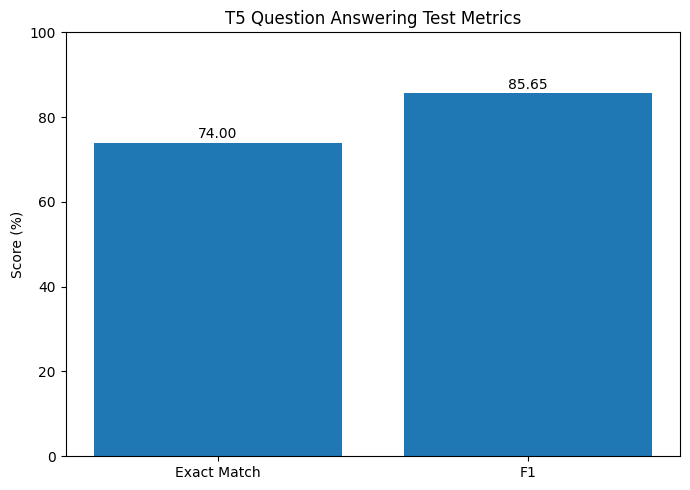

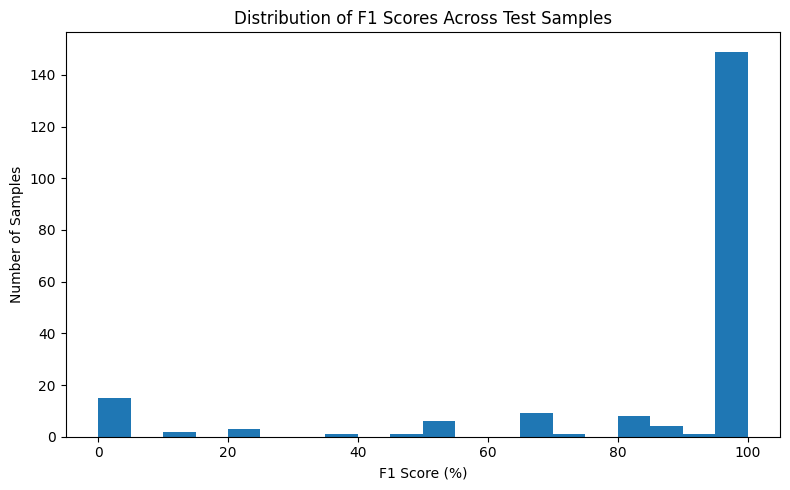

In [24]:
metric_names = ["Exact Match", "F1"]
metric_values = [final_metrics["test_exact_match"], final_metrics["test_f1"]]

plt.figure(figsize=(7, 5))
plt.bar(metric_names, metric_values)
plt.title("T5 Question Answering Test Metrics")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

for i, value in enumerate(metric_values):
  plt.text(i, value + 1, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig("outputs/metric_summary.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(predictions_df["f1"] * 100, bins=20)
plt.title("Distribution of F1 Scores Across Test Samples")
plt.xlabel("F1 Score (%)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("outputs/f1_distribution.png", dpi=150)
plt.show()


## 16. Inference Function

Use this function to ask a question based on a custom context.


In [25]:
def answer_question(question, context, max_new_tokens=MAX_TARGET_LENGTH):
  model.eval()

  input_text = build_t5_input(question, context)
  inputs = tokenizer(
    input_text,
    return_tensors="pt",
    max_length=MAX_SOURCE_LENGTH,
    truncation=True
  ).to(device)

  with torch.no_grad():
    generated_ids = model.generate(
      **inputs,
      max_new_tokens=max_new_tokens,
      num_beams=4,
      early_stopping=True
    )

  return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

custom_context = (
  "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. "
  "It is named after the engineer Gustave Eiffel, whose company designed and built the tower."
)

custom_question = "Who is the Eiffel Tower named after?"

answer_question(custom_question, custom_context)


'Gustave Eiffel'

## 17. Final Notes

This notebook is designed for assignment submission, so the focus is not only the final score but the completeness of the workflow:

- reproducible configuration
- clear preprocessing
- correct T5 input-output formatting
- training and evaluation
- inference
- error analysis